In [33]:
import warnings
warnings.filterwarnings('ignore')
!pip install numpy
!pip install -U "cupy-cuda13x[ctk]"
!pip install types-array-api
!pip install array-api-compat

In [34]:
!git clone --branch measurement-optimize https://github.com/Ankit-539/QuanSToS.git

Cloning into 'QuanSToS'...
remote: Enumerating objects: 210, done.
remote: Counting objects: 100% (210/210), done.
remote: Compressing objects: 100% (142/142), done.
remote: Total 210 (delta 135), reused 125 (delta 66), pack-reused 0 (from 0)
Receiving objects: 100% (210/210), 2.70 MiB | 7.11 MiB/s, done.
Resolving deltas: 100% (135/135), done.


In [35]:
%cd QuanSToS

/content/QuanSToS/QuanSToS/QuanSToS


In [36]:
from time import perf_counter

# import cupy as cp
import numpy as np
import array_api_compat
import array_api_compat.cupy as cp
import math
import matplotlib.pyplot as plt

from src import (
    get_random_haar,
    get_random_mixed,
    get_random_product,
    get_random_product_pole_biased,
    inverse_estimator,
    mle,
    fidelity,
    negativity,
    pauli_measurement,
    plot_counts,
    bloch_vector,
    benchmark_function,
    benchmark_pauli_measurement
)

# Virtual Pauli measurements

XXX  [12539 12599 12599 12485 12643 12297 12430 12408]
XXY  [12505 12543 12486 12689 12186 12565 12576 12450]
XXZ  [21274  3717 21459  3793 21306  3719 21089  3643]
XYX  [12652 12552 12423 12533 12633 12222 12571 12414]
XYY  [12451 12534 12523 12328 12627 12516 12598 12423]
XYZ  [21157  3879 21200  3762 21308  3783 21084  3827]
XZX  [21354 21256  3786  3712 21351 21125  3775  3641]
XZY  [21254 21236  3855  3752 21156 21257  3743  3747]
XZZ  [38874  3699  3712  3713 38674  3831  3750  3747]
YXX  [12461 12536 12371 12285 12753 12778 12296 12520]
YXY  [12583 12405 12512 12527 12567 12469 12527 12410]
YXZ  [21276  3687 21519  3763 21144  3754 21125  3732]
YYX  [12467 12431 12410 12548 12523 12638 12564 12419]
YYY  [12519 12302 12559 12430 12462 12633 12525 12570]
YYZ  [20960  3698 21485  3832 21135  3789 21296  3805]
YZX  [21277 21166  3768  3827 21162 21195  3837  3768]
YZY  [21332 20987  3778  3767 21329 21383  3747  3677]
YZZ  [38769  3747  3718  3767 38821  3728  3725  3725]
ZXX  [2130

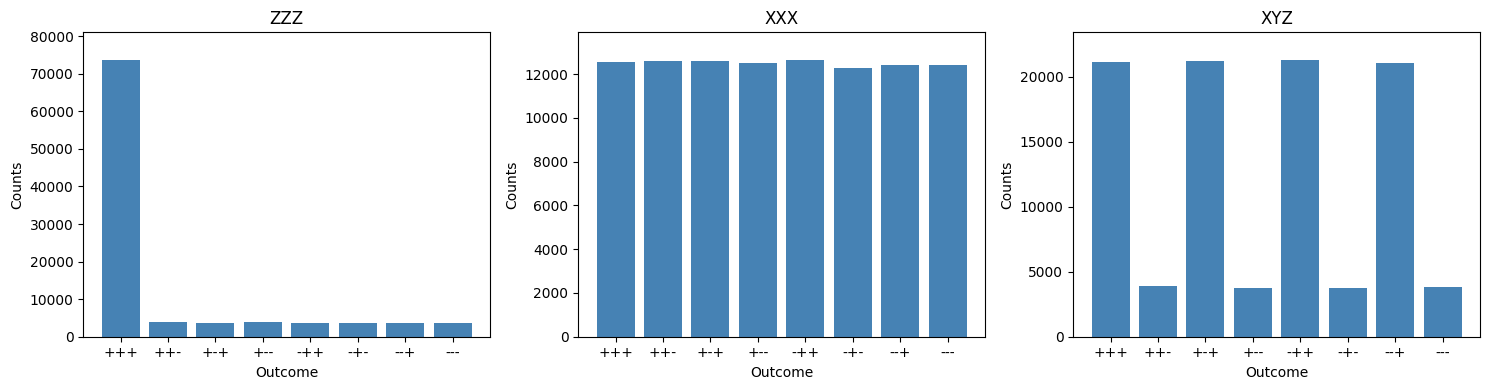

In [37]:
p = 0.7
rho_000 = np.zeros((8, 8), dtype=np.complex128)
rho_000[0, 0] = 1
rho_partial = (p*rho_000 + (1-p)*np.eye(8, dtype=np.complex128)/8)

N = 100_000

result = pauli_measurement(rho_partial, N)

print(result)

plot_counts(result,["ZZZ", "XXX", "XYZ"])

XXX  [12562 12399 12495 12512 12531 12547 12422 12532]
XXY  [12507 12446 12466 12368 12464 12743 12518 12488]
XXZ  [24949     0 24965     0 25207     0 24879     0]
XYX  [12388 12555 12422 12495 12322 12623 12675 12520]
XYY  [12445 12680 12520 12390 12465 12394 12536 12570]
XYZ  [25031     0 24974     0 25032     0 24963     0]
XZX  [24955 24909     0     0 25127 25009     0     0]
XZY  [25075 24799     0     0 24967 25159     0     0]
XZZ  [50282     0     0     0 49718     0     0     0]
YXX  [12668 12571 12483 12456 12440 12426 12609 12347]
YXY  [12574 12483 12448 12485 12493 12630 12428 12459]
YXZ  [25090     0 24824     0 25025     0 25061     0]
YYX  [12524 12490 12526 12406 12473 12606 12425 12550]
YYY  [12492 12565 12240 12585 12548 12576 12478 12516]
YYZ  [24957     0 25075     0 25025     0 24943     0]
YZX  [25095 24784     0     0 25190 24931     0     0]
YZY  [25004 24912     0     0 25071 25013     0     0]
YZZ  [49890     0     0     0 50110     0     0     0]
ZXX  [2518

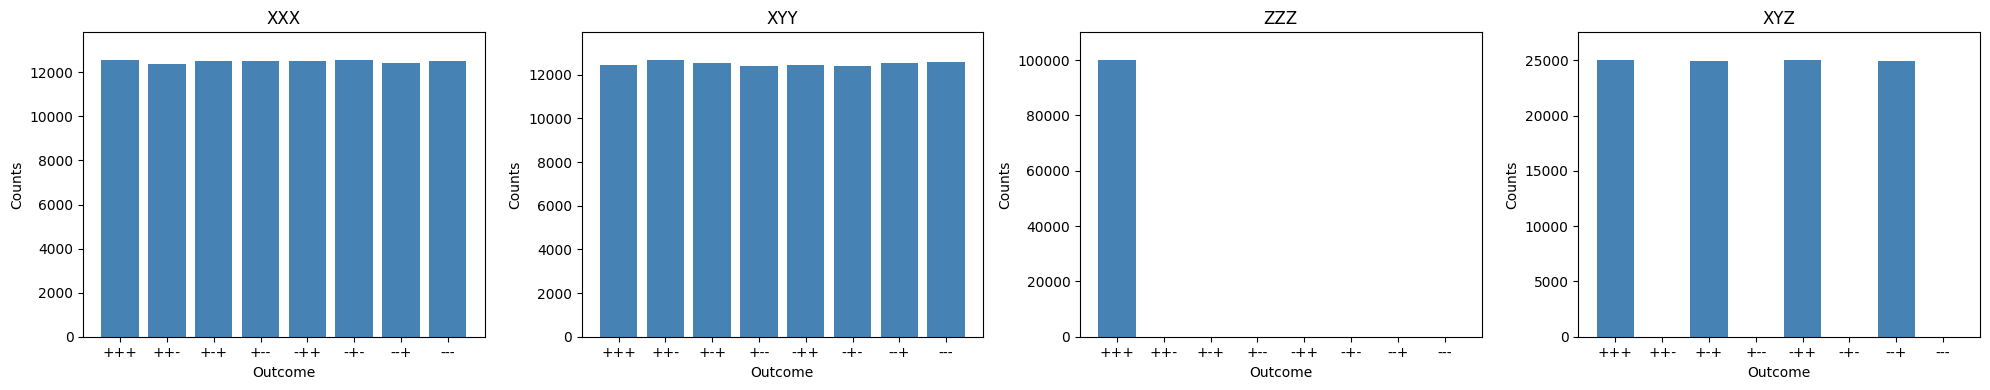

In [38]:
rho_000_cp = cp.zeros((8, 8), dtype=cp.complex128)
rho_000_cp[0, 0] = 1

N = 100_000

result_cp = pauli_measurement(rho_000_cp, N)

print(result_cp)
plot_counts(
    result_cp,
    ["XXX", "XYY", "ZZZ", "XYZ"]
)

100000


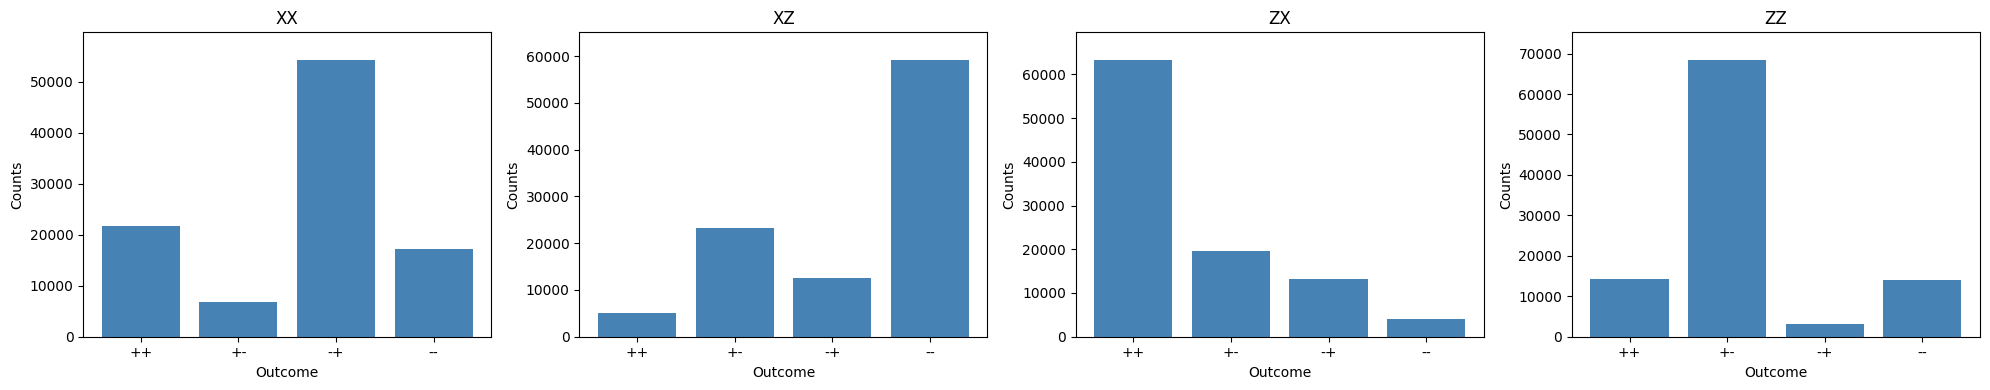

In [39]:
rho = get_random_product(2, array_api_compat.numpy, np.random)

N = 100_000

result = pauli_measurement(rho, N)

print(result.N)

plot_counts(result, ["XX", "XZ", "ZX", "ZZ"])

100000


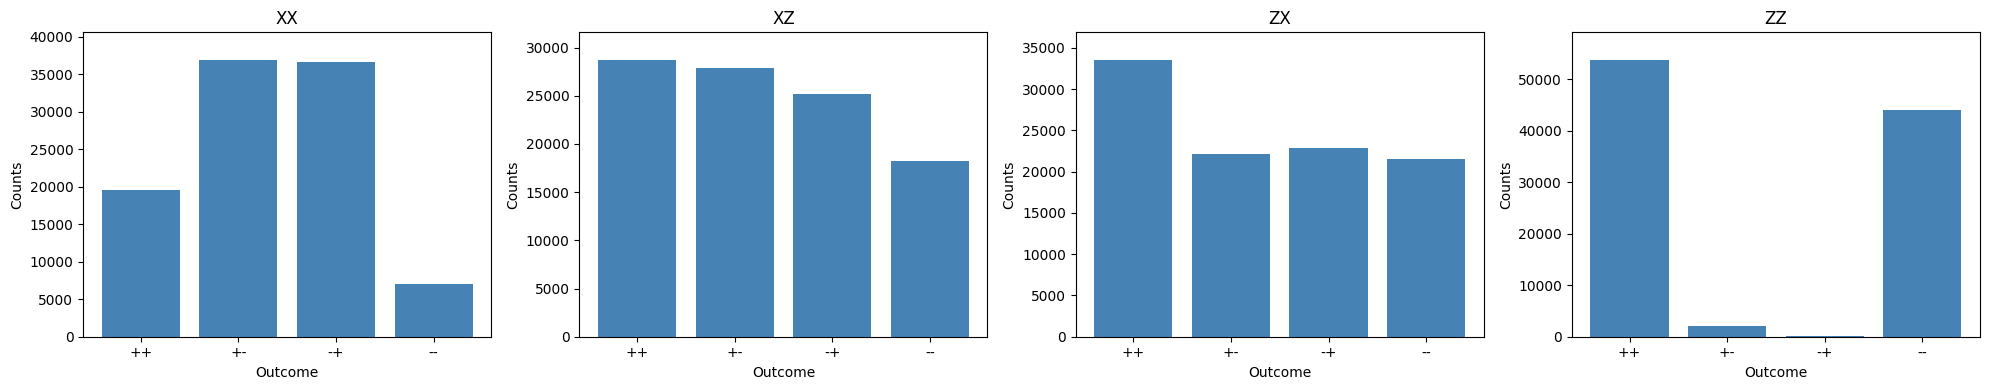

In [40]:
rho = get_random_haar(2, array_api_compat.numpy, np.random)

N = 100_000

result = pauli_measurement(rho, N)

print(result.N)

plot_counts(result, ["XX", "XZ", "ZX", "ZZ"])

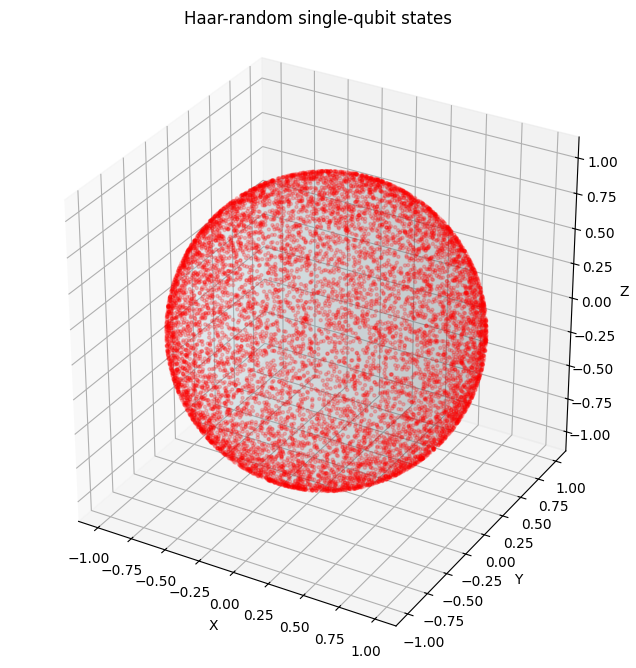

In [41]:
bloch_vectors = []
num_samples = 10000

for _ in range(num_samples):
    rho = get_random_haar(1, array_api_compat.numpy, np.random)
    r = bloch_vector(rho)
    bloch_vectors.append(r)

rng = np.random.default_rng(42)

vectors_np = np.asarray(bloch_vectors)

fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection="3d")

# Bloch sphere
u = np.linspace(0, 2 * np.pi, 100)
v = np.linspace(0, np.pi, 50)

x_sphere = np.outer(np.cos(u), np.sin(v))
y_sphere = np.outer(np.sin(u), np.sin(v))
z_sphere = np.outer(np.ones_like(u), np.cos(v))

ax.plot_surface(
    x_sphere,
    y_sphere,
    z_sphere,
    color="lightblue",
    alpha=0.15,
    linewidth=0
)

# Haar-random states
ax.scatter(
    vectors_np[:, 0],
    vectors_np[:, 1],
    vectors_np[:, 2],
    s=5,
    alpha=0.2,
    color="red"
)

ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")

ax.set_title("Haar-random single-qubit states")

ax.set_box_aspect([1, 1, 1])

plt.show()

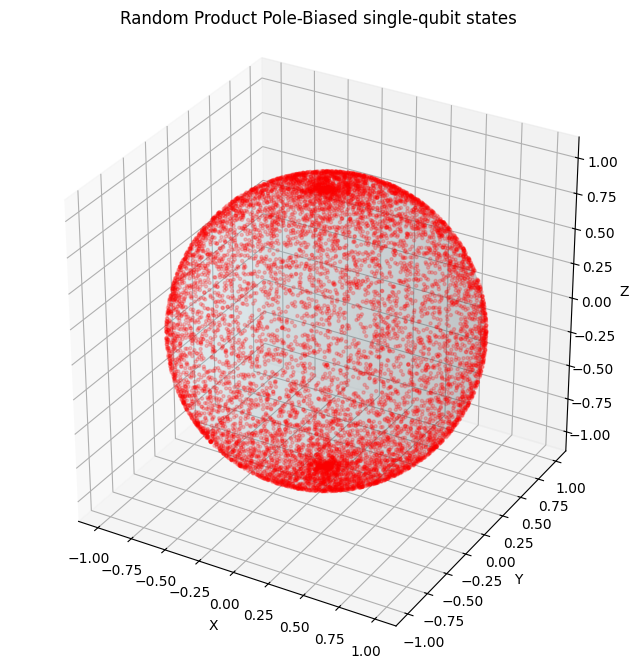

In [42]:
bloch_vectors = []
num_samples = 10000

for _ in range(num_samples):
    rho = get_random_product_pole_biased(1, array_api_compat.numpy, np.random)
    r = bloch_vector(rho)
    bloch_vectors.append(r)

rng = np.random.default_rng(42)

vectors_np = np.asarray(bloch_vectors)

fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection="3d")

# Bloch sphere
u = np.linspace(0, 2 * np.pi, 100)
v = np.linspace(0, np.pi, 50)

x_sphere = np.outer(np.cos(u), np.sin(v))
y_sphere = np.outer(np.sin(u), np.sin(v))
z_sphere = np.outer(np.ones_like(u), np.cos(v))

ax.plot_surface(
    x_sphere,
    y_sphere,
    z_sphere,
    color="lightblue",
    alpha=0.15,
    linewidth=0
)

# Haar-random states
ax.scatter(
    vectors_np[:, 0],
    vectors_np[:, 1],
    vectors_np[:, 2],
    s=5,
    alpha=0.2,
    color="red"
)

ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")

ax.set_title("Random Product Pole-Biased single-qubit states")

ax.set_box_aspect([1, 1, 1])

plt.show()

In [43]:
xp = np

zero = xp.asarray([1, 0], dtype=xp.complex128)
plus = xp.asarray([1, 1], dtype=xp.complex128) / xp.sqrt(2)

psi = xp.kron(zero, plus)
rho = xp.outer(psi, xp.conj(psi))

result = pauli_measurement(rho, 100_000)

for measurement in ["ZX", "XZ"]:
    i = result.measurements.index(measurement)
    print(measurement, result.counts[i])

ZX [100000      0      0      0]
XZ [24952 24812 25069 25167]


XY [25008 25046 24857 25089]
YX [50118     0 49882     0]


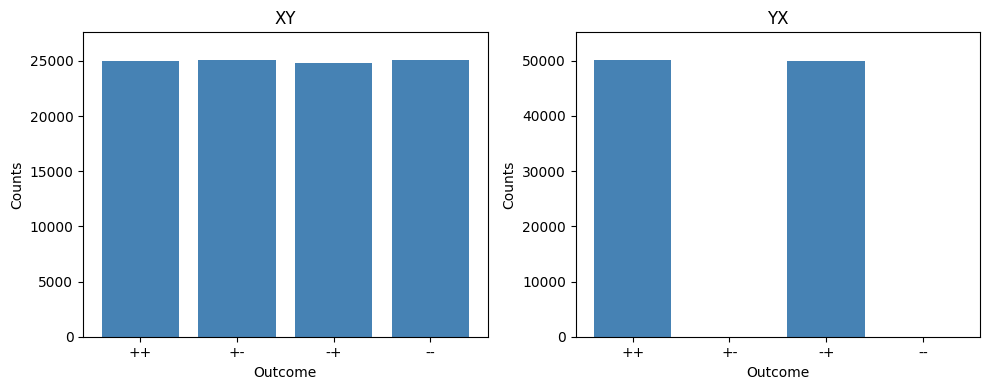

In [44]:
zero = xp.asarray([1, 0], dtype=xp.complex128)
one  = xp.asarray([0, 1], dtype=xp.complex128)

plus_x = (zero + one) / xp.sqrt(2)
plus_y = (zero + 1j * one) / xp.sqrt(2)

psi = xp.kron(plus_x, plus_y)
rho = xp.outer(psi, xp.conj(psi))

for measurement in ["XY", "YX"]:
    i = result.measurements.index(measurement)
    print(measurement, result.counts[i])

plot_counts(result, ["XY", "YX"])

# Hardware Benchmarking

Sampling

In [45]:
benchmarks = {
    "Product": (
        get_random_product,
        range(2, 15)
    ),

    "Product (pole biased)": (
        get_random_product_pole_biased,
        range(2, 15)
    ),

    "Haar": (
        get_random_haar,
        range(2, 15)
    ),

    "Mixed": (
        get_random_mixed,
        range(2, 11)
    ),
}

functions = {
    "Product": get_random_product,
    "Product (pole biased)": get_random_product_pole_biased,
    "Haar": get_random_haar,
    "Mixed": get_random_mixed,
}

rng_np = np.random.default_rng(42)
rng_cp = cp.random.RandomState(42)

### CPU (NumPy)

In [46]:
results_np = {}

for name, (func, n_values) in benchmarks.items():

    print(f"Benchmarking NumPy: {name}")

    results_np[name] = benchmark_function(
        func,
        n_values,
        np,
        rng_np,
        repeats=20
    )

Benchmarking NumPy: Product


KeyboardInterrupt: 

### GPU (CuPy)

In [ ]:
results_cp = {}

for name, (func, n_values) in benchmarks.items():

    print(f"Benchmarking CuPy: {name}")

    results_cp[name] = benchmark_function(
        func,
        n_values,
        cp,
        rng_cp,
        repeats=10
    )

Benchmarking CuPy: Product
Benchmarking CuPy: Product (pole biased)
Benchmarking CuPy: Haar
Benchmarking CuPy: Mixed


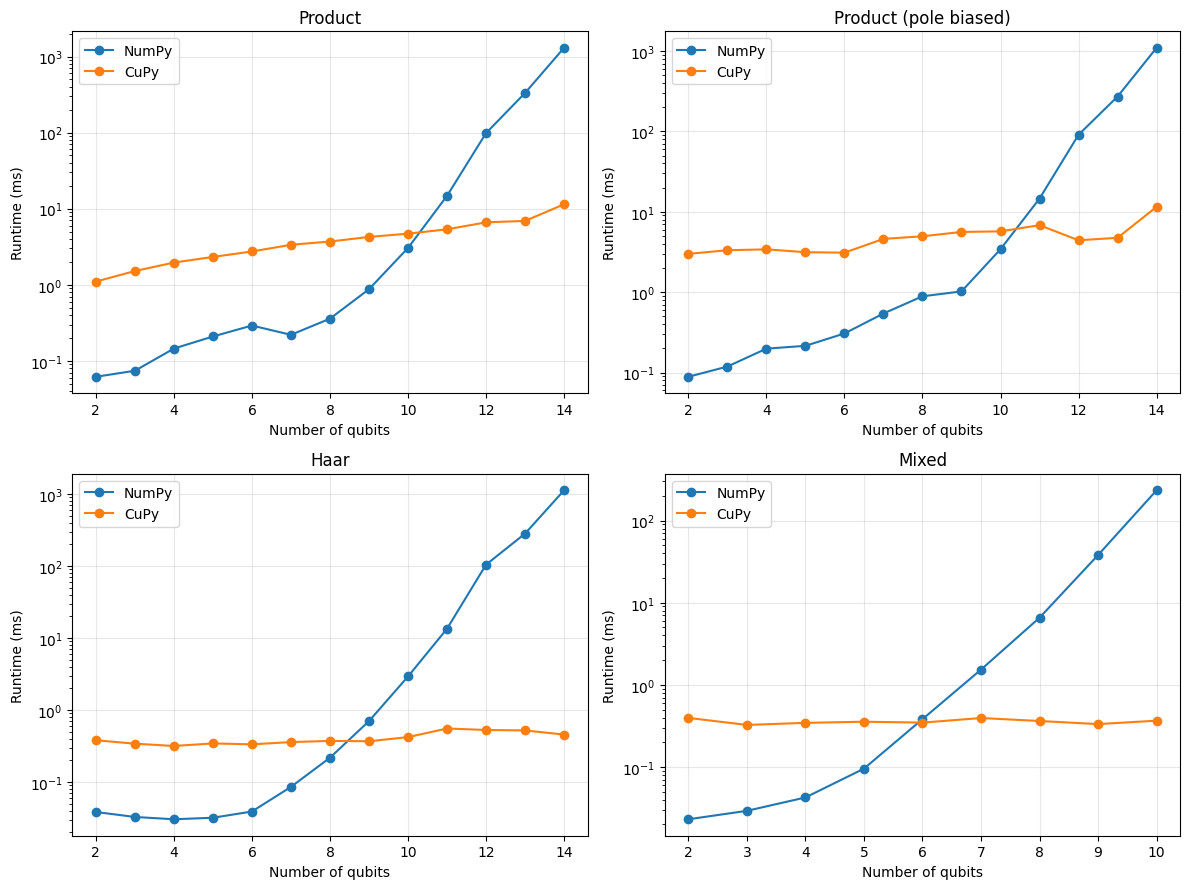

In [ ]:
fig, axes = plt.subplots(
    2, 2,
    figsize=(12, 9)
)

axes = axes.flatten()

for ax, (name, (func, n_values)) in zip(axes, benchmarks.items()):

    n_values = list(n_values)

    ax.plot(
        n_values,
        results_np[name],
        marker="o",
        label="NumPy"
    )

    ax.plot(
        n_values,
        results_cp[name],
        marker="o",
        label="CuPy"
    )

    ax.set_title(name)
    ax.set_xlabel("Number of qubits")
    ax.set_ylabel("Runtime (ms)")
    ax.set_yscale("log")

    ax.grid(True, alpha=0.3)
    ax.legend()

plt.tight_layout()
plt.show()

Virtual Measurement

In [47]:
n_values = range(2, 7)

N = 10_000

### CPU (NumPy)

In [ ]:
results_np = {}

for n in n_values:

    print(f"Benchmarking n = {n}")

    rho_np = get_random_haar(n, np, rng_np)

    results_np[n] = benchmark_pauli_measurement(pauli_measurement, rho_np, N, np, repeats=5)

Benchmarking n = 2
Benchmarking n = 3
Benchmarking n = 4
Benchmarking n = 5
Benchmarking n = 6


### GPU (CuPy)

In [48]:
results_cp = {}

for n in n_values:

    print(f"Benchmarking n = {n}")

    rho_cp = get_random_haar(n, cp, rng_cp)

    results_cp[n] = benchmark_pauli_measurement(pauli_measurement, rho_cp, N, cp, repeats=5)

Benchmarking n = 2
Benchmarking n = 3
Benchmarking n = 4
Benchmarking n = 5
Benchmarking n = 6


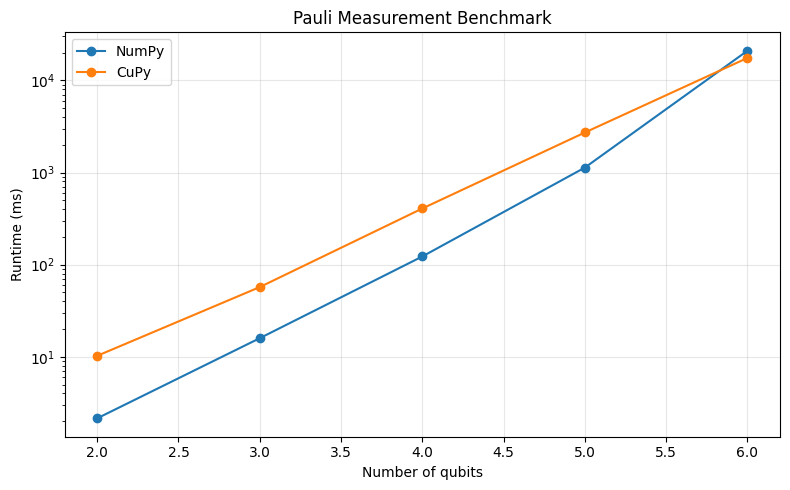

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(
    list(results_np.keys()),
    list(results_np.values()),
    marker="o",
    label="NumPy"
)

plt.plot(
    list(results_cp.keys()),
    list(results_cp.values()),
    marker="o",
    label="CuPy"
)

plt.yscale("log")

plt.xlabel("Number of qubits")
plt.ylabel("Runtime (ms)")
plt.title("Pauli Measurement Benchmark")

plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

# Noise Resilience

### Data generation

In [ ]:
n = 4
Ns = list(2**i for i in range(3, 20))

# xp = cp
xp = np

haar_rho = get_random_haar(n, xp)
# X = xp.asarray([
#     [0, 1],
#     [1, 0]
# ], dtype=xp.complex128)
# haar_rho = (xp.identity(2**n) + xp.kron(X, X)) / 2**n
prod_rho = get_random_product(n, xp)

haar_countss = []
prod_countss = []
for N in Ns:
    haar_counts = pauli_measurement(haar_rho, N).counts
    prod_counts = pauli_measurement(prod_rho, N).counts
    haar_countss.append(haar_counts)
    prod_countss.append(prod_counts)

### Estimation

In [ ]:
haar_fs = []
prod_fs = []
haar_ns = []
prod_ns = []
for i, N in enumerate(Ns):
    haar_counts = haar_countss[i]
    prod_counts = prod_countss[i]

    haar_est = inverse_estimator(haar_counts)
    prod_est = inverse_estimator(prod_counts)

    haar_f = float(xp.linalg.norm(haar_rho - haar_est))
    prod_f = float(xp.linalg.norm(prod_rho - prod_est))
    # haar_f = fidelity(haar_rho, haar_est)
    # prod_f = fidelity(prod_rho, prod_est)
    haar_fs.append(haar_f)
    prod_fs.append(prod_f)

    haar_n = float(negativity(haar_est))
    prod_n = float(negativity(prod_est))
    haar_ns.append(haar_n)
    prod_ns.append(prod_n)

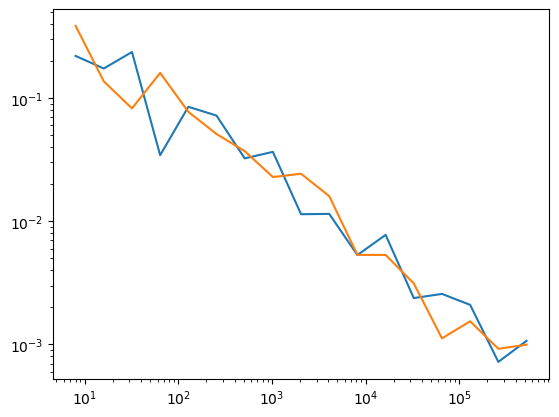

In [ ]:
plt.plot(Ns, haar_ns)
plt.plot(Ns, prod_ns)

plt.xscale('log')
plt.yscale('log')

# Advanced Protocols (Classical Shadows)